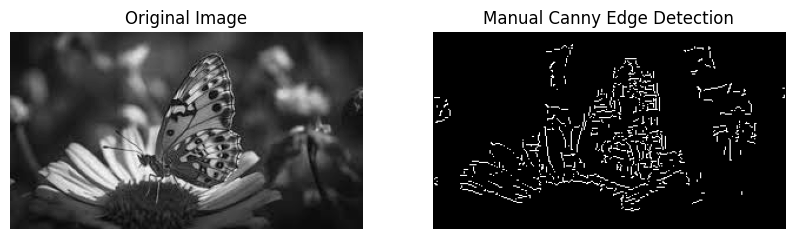

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def manual_canny(image_path, sigma=1.0, low_threshold=50, high_threshold=150):
    """Perform Canny edge detection manually using Sobel, NMS, and thresholding."""
    
    # Read image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(image, (5, 5), sigma)
    
    # Compute Sobel gradients
    Gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    
    # Compute Gradient Magnitude and Direction
    gradient_magnitude = np.hypot(Gx, Gy)
    gradient_magnitude = (gradient_magnitude / gradient_magnitude.max()) * 255
    gradient_direction = np.arctan2(Gy, Gx) * (180 / np.pi)
    gradient_direction[gradient_direction < 0] += 180  # Normalize direction

    # Non-Maximum Suppression (NMS)
    nms = np.zeros_like(gradient_magnitude, dtype=np.uint8)
    for i in range(1, gradient_magnitude.shape[0] - 1):
        for j in range(1, gradient_magnitude.shape[1] - 1):
            direction = gradient_direction[i, j]
            magnitude = gradient_magnitude[i, j]
            
            # Identify pixel neighbors based on gradient direction
            if (0 <= direction < 22.5) or (157.5 <= direction <= 180):
                before, after = gradient_magnitude[i, j-1], gradient_magnitude[i, j+1]
            elif (22.5 <= direction < 67.5):
                before, after = gradient_magnitude[i-1, j+1], gradient_magnitude[i+1, j-1]
            elif (67.5 <= direction < 112.5):
                before, after = gradient_magnitude[i-1, j], gradient_magnitude[i+1, j]
            elif (112.5 <= direction < 157.5):
                before, after = gradient_magnitude[i-1, j-1], gradient_magnitude[i+1, j+1]
            
            # Suppress non-maxima
            if magnitude >= before and magnitude >= after:
                nms[i, j] = magnitude
            else:
                nms[i, j] = 0

    # Double Thresholding
    strong_edges = (nms >= high_threshold).astype(np.uint8) * 255
    weak_edges = ((nms >= low_threshold) & (nms < high_threshold)).astype(np.uint8) * 255
    
    # Edge tracking by hysteresis
    edges = np.zeros_like(nms, dtype=np.uint8)
    strong_pixels = np.argwhere(strong_edges)
    
    for y, x in strong_pixels:
        edges[y, x] = 255
        
        # Check neighbors of strong edges
        neighbors = [
            (y-1, x-1), (y-1, x), (y-1, x+1),
            (y, x-1),             (y, x+1),
            (y+1, x-1), (y+1, x), (y+1, x+1)
        ]
        for ny, nx in neighbors:
            if (0 <= ny < nms.shape[0]) and (0 <= nx < nms.shape[1]):
                if weak_edges[ny, nx] == 255:
                    edges[ny, nx] = 255

    # Display the images using Matplotlib
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(edges, cmap="gray")
    plt.title("Manual Canny Edge Detection")
    plt.axis("off")

    plt.show()

# Run the function
manual_canny(r"C:\Users\JAI\Downloads\images.jpg",10,10,75)

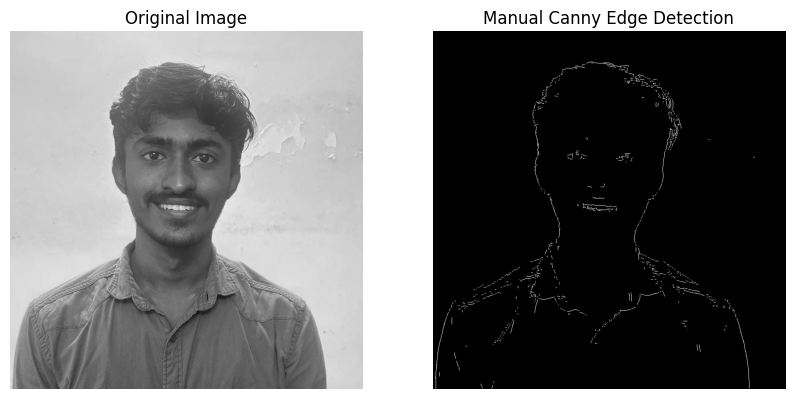

In [7]:
manual_canny(r"C:\Users\JAI\Downloads\Ezhil.jpg",10,10,75)

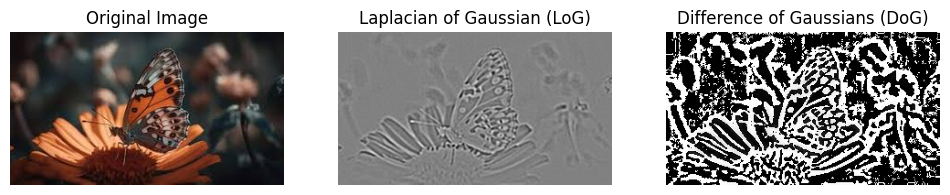

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def laplacian_of_gaussian(image):
    """Apply Laplacian of Gaussian (LoG) edge detection."""
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    
    # Apply Laplacian
    log = cv2.Laplacian(blurred, cv2.CV_64F)
    
    return log

def difference_of_gaussians(image, sigma1=1.0, sigma2=2.0):
    """Apply Difference of Gaussians (DoG) edge detection."""
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian Blur with two different sigmas
    gaussian1 = cv2.GaussianBlur(image, (0, 0), sigma1)
    gaussian2 = cv2.GaussianBlur(image, (0, 0), sigma2)
    
    # Compute Difference of Gaussians
    dog = gaussian1 - gaussian2
    
    return dog

def display_results(image):
    """Display original image, LoG, and DoG."""
    log_result = laplacian_of_gaussian(image)
    dog_result = difference_of_gaussians(image)
    
    # Plot the images
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(log_result, cmap="gray")
    plt.title("Laplacian of Gaussian (LoG)")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(dog_result, cmap="gray")
    plt.title("Difference of Gaussians (DoG)")
    plt.axis("off")
    
    plt.show()
    
image = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")  # Load an image
display_results(image)



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-83.0..62.0].


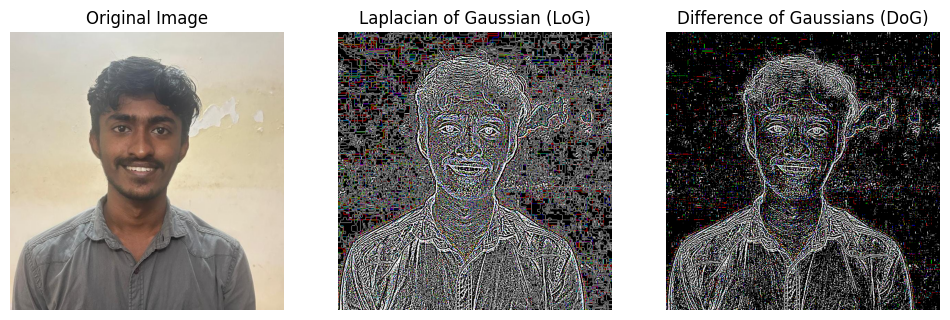

In [8]:
image = cv2.imread(r"C:\Users\JAI\Downloads\Ezhil.jpg")  # Load an image
display_results(image)

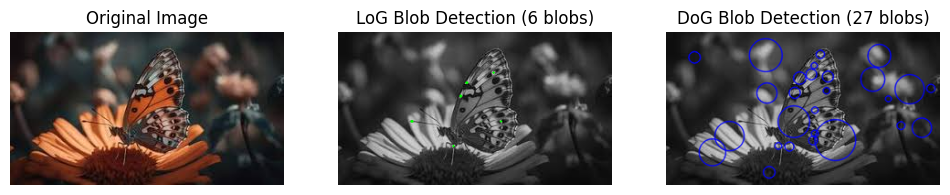

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def laplacian_of_gaussian(image):
    """Applies Laplacian of Gaussian (LoG) for blob detection."""
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    log_result = cv2.Laplacian(blurred, cv2.CV_64F)
    return log_result

def difference_of_gaussians(image):
    """Applies Difference of Gaussians (DoG) for blob detection."""
    gaussian1 = cv2.GaussianBlur(image, (5, 5), 1)
    gaussian2 = cv2.GaussianBlur(image, (5, 5), 2)
    dog_result = gaussian1 - gaussian2
    return dog_result

def blob_detection_log(image):
    """Detect blobs using Laplacian of Gaussian (LoG)."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    log_result = laplacian_of_gaussian(gray)

    # Convert to absolute values and normalize
    log_result = np.uint8(np.abs(log_result))

    # Apply binary thresholding to highlight blobs
    _, thresholded = cv2.threshold(log_result, 50, 255, cv2.THRESH_BINARY)

    # Find contours (blobs)
    contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw detected blobs
    result = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(result, contours, -1, (0, 255, 0), 2)

    return result, contours

def blob_detection_dog(image):
    """Detect blobs using Difference of Gaussians (DoG)."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    dog_result = difference_of_gaussians(gray)

    # Normalize DoG result
    dog_result = np.uint8((dog_result - dog_result.min()) / (dog_result.max() - dog_result.min()) * 255)

    # Threshold to highlight blobs
    _, thresholded = cv2.threshold(dog_result, 50, 255, cv2.THRESH_BINARY)

    # Use OpenCV’s SimpleBlobDetector
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = 30
    params.maxArea = 5000
    params.filterByCircularity = False
    params.filterByConvexity = False
    params.filterByInertia = False

    detector = cv2.SimpleBlobDetector_create(params)
    keypoints = detector.detect(thresholded)

    # Draw detected blobs
    result = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    result = cv2.drawKeypoints(result, keypoints, None, (0, 0, 255), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    return result, keypoints

def display_blob_results(image):
    """Display LoG and DoG blob detection results."""
    log_result, log_contours = blob_detection_log(image)
    dog_result, dog_keypoints = blob_detection_dog(image)

    # Plot the images
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(log_result, cmap="gray")
    plt.title(f"LoG Blob Detection ({len(log_contours)} blobs)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(dog_result, cmap="gray")
    plt.title(f"DoG Blob Detection ({len(dog_keypoints)} blobs)")
    plt.axis("off")

    plt.show()

# Load an image
image = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")
display_blob_results(image)


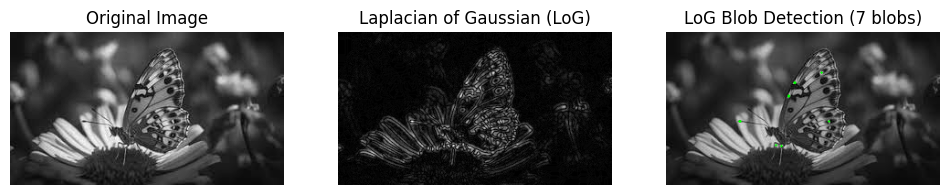

array([[[16, 16, 16],
        [16, 16, 16],
        [16, 16, 16],
        ...,
        [14, 14, 14],
        [14, 14, 14],
        [14, 14, 14]],

       [[16, 16, 16],
        [16, 16, 16],
        [16, 16, 16],
        ...,
        [14, 14, 14],
        [14, 14, 14],
        [14, 14, 14]],

       [[16, 16, 16],
        [16, 16, 16],
        [16, 16, 16],
        ...,
        [15, 15, 15],
        [15, 15, 15],
        [15, 15, 15]],

       ...,

       [[25, 25, 25],
        [25, 25, 25],
        [24, 24, 24],
        ...,
        [14, 14, 14],
        [14, 14, 14],
        [14, 14, 14]],

       [[24, 24, 24],
        [24, 24, 24],
        [23, 23, 23],
        ...,
        [14, 14, 14],
        [14, 14, 14],
        [14, 14, 14]],

       [[24, 24, 24],
        [23, 23, 23],
        [22, 22, 22],
        ...,
        [14, 14, 14],
        [14, 14, 14],
        [14, 14, 14]]], dtype=uint8)

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def blob_detection_log(image_path, threshold=50):
    """
    Detects blobs in an image using the Laplacian of Gaussian (LoG) method.
    
    Parameters:
    - image_path: str, path to the input image.
    - threshold: int, threshold for binary segmentation after applying LoG.
    
    Returns:
    - result: Image with detected blobs drawn as contours.
    - contours: List of detected blob contours.
    """

    # Load the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        raise ValueError("Image not found. Check the file path.")

    # Apply Gaussian Blur to smooth the image and reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Apply Laplacian operator
    log_result = cv2.Laplacian(blurred, cv2.CV_64F)

    # Convert to absolute values and normalize
    log_result = np.uint8(np.abs(log_result))

    # Apply binary thresholding to highlight blobs
    _, thresholded = cv2.threshold(log_result, threshold, 255, cv2.THRESH_BINARY)

    # Find contours (blobs)
    contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Convert grayscale image to BGR for visualization
    result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(result, contours, -1, (0, 255, 0), 2)  # Draw contours in green

    # Display results using Matplotlib
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(log_result, cmap="gray")
    plt.title("Laplacian of Gaussian (LoG)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(result)
    plt.title(f"LoG Blob Detection ({len(contours)} blobs)")
    plt.axis("off")

    plt.show()

    return result

# Example usage
blob_detection_log(r"C:\Users\JAI\Downloads\images.jpg")


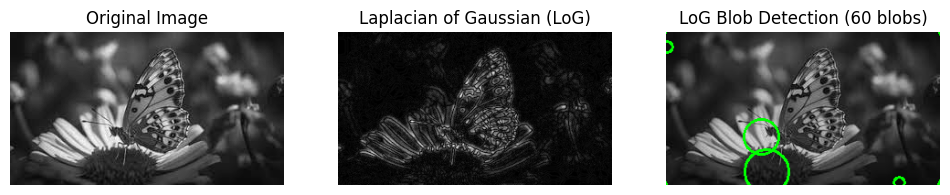

(array([[[  0, 255,   0],
         [  0, 255,   0],
         [ 16,  16,  16],
         ...,
         [  0, 255,   0],
         [  0, 255,   0],
         [  0, 255,   0]],
 
        [[  0, 255,   0],
         [ 16,  16,  16],
         [ 16,  16,  16],
         ...,
         [ 14,  14,  14],
         [  0, 255,   0],
         [  0, 255,   0]],
 
        [[  0, 255,   0],
         [ 16,  16,  16],
         [ 16,  16,  16],
         ...,
         [ 15,  15,  15],
         [  0, 255,   0],
         [  0, 255,   0]],
 
        ...,
 
        [[  0, 255,   0],
         [ 25,  25,  25],
         [ 24,  24,  24],
         ...,
         [ 14,  14,  14],
         [  0, 255,   0],
         [  0, 255,   0]],
 
        [[  0, 255,   0],
         [  0, 255,   0],
         [ 23,  23,  23],
         ...,
         [  0, 255,   0],
         [  0, 255,   0],
         [  0, 255,   0]],
 
        [[  0, 255,   0],
         [  0, 255,   0],
         [ 22,  22,  22],
         ...,
         [  0, 255,   0],
  

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def blob_detection_log(image_path):
    """
    Detects blobs using the Laplacian of Gaussian (LoG) method with improvements.
    
    Parameters:
    - image_path: str, path to the input image.
    
    Returns:
    - result: Image with detected blobs drawn as contours.
    - keypoints: List of detected blob keypoints.
    """

    # Load the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        raise ValueError("Image not found. Check the file path.")

    # Apply Gaussian Blur with multiple scales
    blurred1 = cv2.GaussianBlur(image, (5, 5), 1)
    blurred2 = cv2.GaussianBlur(image, (9, 9), 2)
    
    # Compute the Laplacian of both blurred images
    log1 = cv2.Laplacian(blurred1, cv2.CV_64F)
    log2 = cv2.Laplacian(blurred2, cv2.CV_64F)

    # Combine responses
    log_result = np.abs(log1) + np.abs(log2)

    # Normalize and convert to uint8
    log_result = np.uint8((log_result - log_result.min()) / (log_result.max() - log_result.min()) * 255)

    # Apply adaptive thresholding
    thresholded = cv2.adaptiveThreshold(log_result, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

    # Find contours (blobs)
    contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Convert grayscale image to BGR for visualization
    result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Draw detected blobs as circles
    for contour in contours:
        (x, y), radius = cv2.minEnclosingCircle(contour)
        center = (int(x), int(y))
        radius = int(radius)
        if radius > 3:  # Filter out small noise
            cv2.circle(result, center, radius, (0, 255, 0), 2)  # Green circles

    # Display results using Matplotlib
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(log_result, cmap="gray")
    plt.title("Laplacian of Gaussian (LoG)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(result)
    plt.title(f"LoG Blob Detection ({len(contours)} blobs)")
    plt.axis("off")

    plt.show()

    return result, contours

# Example usage
blob_detection_log(r"C:\Users\JAI\Downloads\images.jpg")


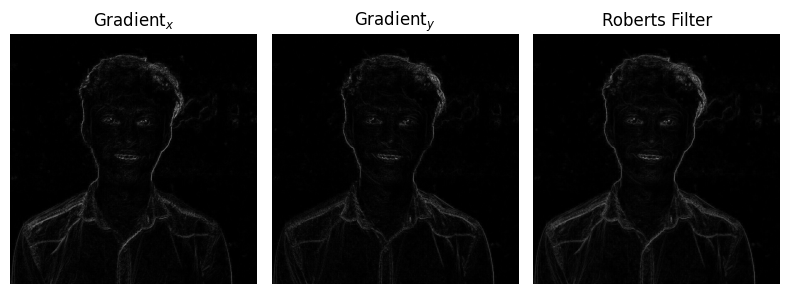

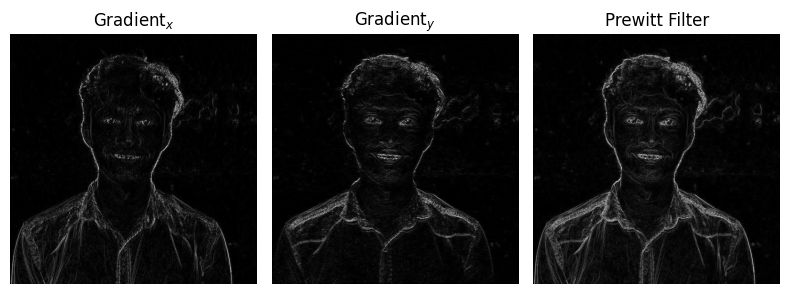

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image in Grayscale
img = cv2.imread(r'C:\Users\JAI\Downloads\Ezhil.jpg', cv2.IMREAD_GRAYSCALE)

def show_img(images, titles):
    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=(8, 8))
    
    for i, axx in enumerate(ax):
        axx.imshow(images[i], cmap='gray')  # Corrected 'grey' to 'gray'
        axx.set_title(titles[i])
        axx.axis("off")

    plt.tight_layout()
    plt.show()  # Moved outside the loop

# Roberts Filter
def robert_filter(img):
    rob_x = np.array([[1, 0], [0, -1]])
    rob_y = np.array([[0, 1], [-1, 0]])
    
    grad_x = cv2.filter2D(img, cv2.CV_64F, rob_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, rob_y)
    
    robert_filt = np.sqrt(np.square(grad_x) + np.square(grad_y))
    
    return np.abs(grad_x).astype(np.uint8), np.abs(grad_y).astype(np.uint8), np.uint8(robert_filt)

grad_x, grad_y, res = robert_filter(img)
show_img([grad_x, grad_y, res], ["Gradient$_x$", "Gradient$_y$", "Roberts Filter"])

# Prewitt Filter
def prewitt_filter(img):
    pr_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    pr_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    
    grad_x = cv2.filter2D(img, cv2.CV_64F, pr_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, pr_y)
    
    prewitt_filt = np.sqrt(np.square(grad_x) + np.square(grad_y))
    
    return np.abs(grad_x).astype(np.uint8), np.abs(grad_y).astype(np.uint8), np.uint8(prewitt_filt)

grad_x, grad_y, res = prewitt_filter(img)
show_img([grad_x, grad_y, res], ["Gradient$_x$", "Gradient$_y$", "Prewitt Filter"])


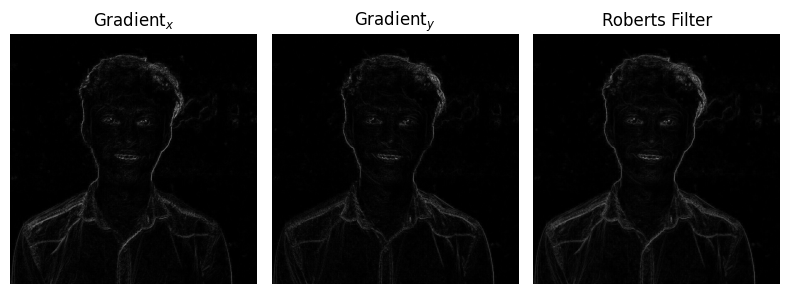

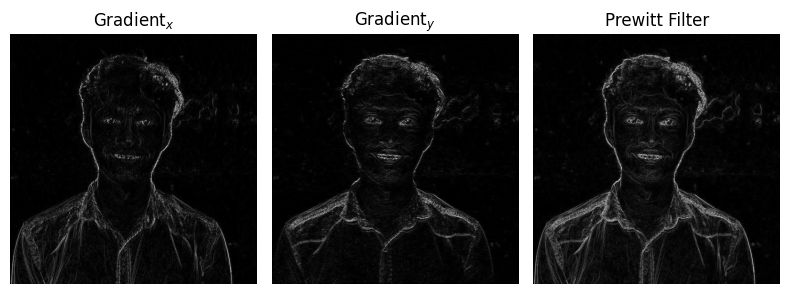

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image in Grayscale
img = cv2.imread(r'C:\Users\JAI\Downloads\Ezhil.jpg', cv2.IMREAD_GRAYSCALE)

def show_img(images, titles):
    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=(8, 8))
    
    for i, axx in enumerate(ax):
        axx.imshow(images[i], cmap='gray')  # Corrected 'grey' to 'gray'
        axx.set_title(titles[i])
        axx.axis("off")

    plt.tight_layout()
    plt.show()  # Moved outside the loop

# Roberts Filter
def robert_filter(img):
    rob_x = np.array([[1, 0], [0, -1]])
    rob_y = np.array([[0, 1], [-1, 0]])
    
    grad_x = cv2.filter2D(img, cv2.CV_64F, rob_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, rob_y)
    
    robert_filt = np.sqrt(np.square(grad_x) + np.square(grad_y))
    
    return np.abs(grad_x).astype(np.uint8), np.abs(grad_y).astype(np.uint8), np.uint8(robert_filt)

grad_x, grad_y, res = robert_filter(img)
show_img([grad_x, grad_y, res], ["Gradient$_x$", "Gradient$_y$", "Roberts Filter"])

# Prewitt Filter
def prewitt_filter(img):
    pr_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    pr_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    
    grad_x = cv2.filter2D(img, cv2.CV_64F, pr_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, pr_y)
    
    prewitt_filt = np.sqrt(np.square(grad_x) + np.square(grad_y))
    
    return np.abs(grad_x).astype(np.uint8), np.abs(grad_y).astype(np.uint8), np.uint8(prewitt_filt)

grad_x, grad_y, res = prewitt_filter(img)
show_img([grad_x, grad_y, res], ["Gradient$_x$", "Gradient$_y$", "Prewitt Filter"])
